# ***Name - H ADITHYA KRISHNAN***
# ***Branch - CSD***
# ***Roll No - 24CD3014***

# ***Evironment Setup & Data Pipeline (Task - 1)***


## ***Imorting Librariers***

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models,callbacks,regularizers
from tensorflow.keras.datasets import mnist, cifar10
from scipy.ndimage import rotate as scipy_rotate
from PIL import Image as PILImage
import warnings
warnings.filterwarnings('ignore')

## ***Checking for gpu***

In [38]:
# Setting the seeds fo data
np.random.seed(42)
tf.random.set_seed(42)
import random
random.seed(42)
gpu = tf.config.experimental.list_physical_devices('GPU')
if(gpu):
  print(f"Gpu detected : {[g.name for g in gpu]}")
else:
  print("No Gpu deteced")

print(f"Why GPU is better than CPU?")
print(f"Reason\nA cpu will work slower than a gpu because gup can do paralle computing whcih helps in fdast compuatation of thousadans of matrixmultiplication involved in CNN.")

Gpu detected : ['/physical_device:GPU:0']
Why GPU is better than CPU?
Reason
A cpu will work slower than a gpu because gup can do paralle computing whcih helps in fdast compuatation of thousadans of matrixmultiplication involved in CNN.


## ***Dataset Exploration***

Info about MNIST data set:
image train_shape: (60000, 28, 28)
label train_shape: (60000,)
image test_shape: (10000, 28, 28)
label test_shape: (10000,)
Pixel value range: [(0, 255)]


Info about CIFAR10 data set:
image train_shape: (50000, 32, 32, 3)
label train_shape: (50000, 1)
image test_shape: (10000, 32, 32, 3)
label test_shape: (10000, 1)
Pixel value range: [(0, 255)]

The class balance of MNIST data set
Class : [0 1 2 3 4 5 6 7 8 9]
Count : [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
The class is mostly well balanced except for digits as there are 60k samples in tarin data with 10 classes and all the classes have roughly 6k samples except for the class 1 and 5 


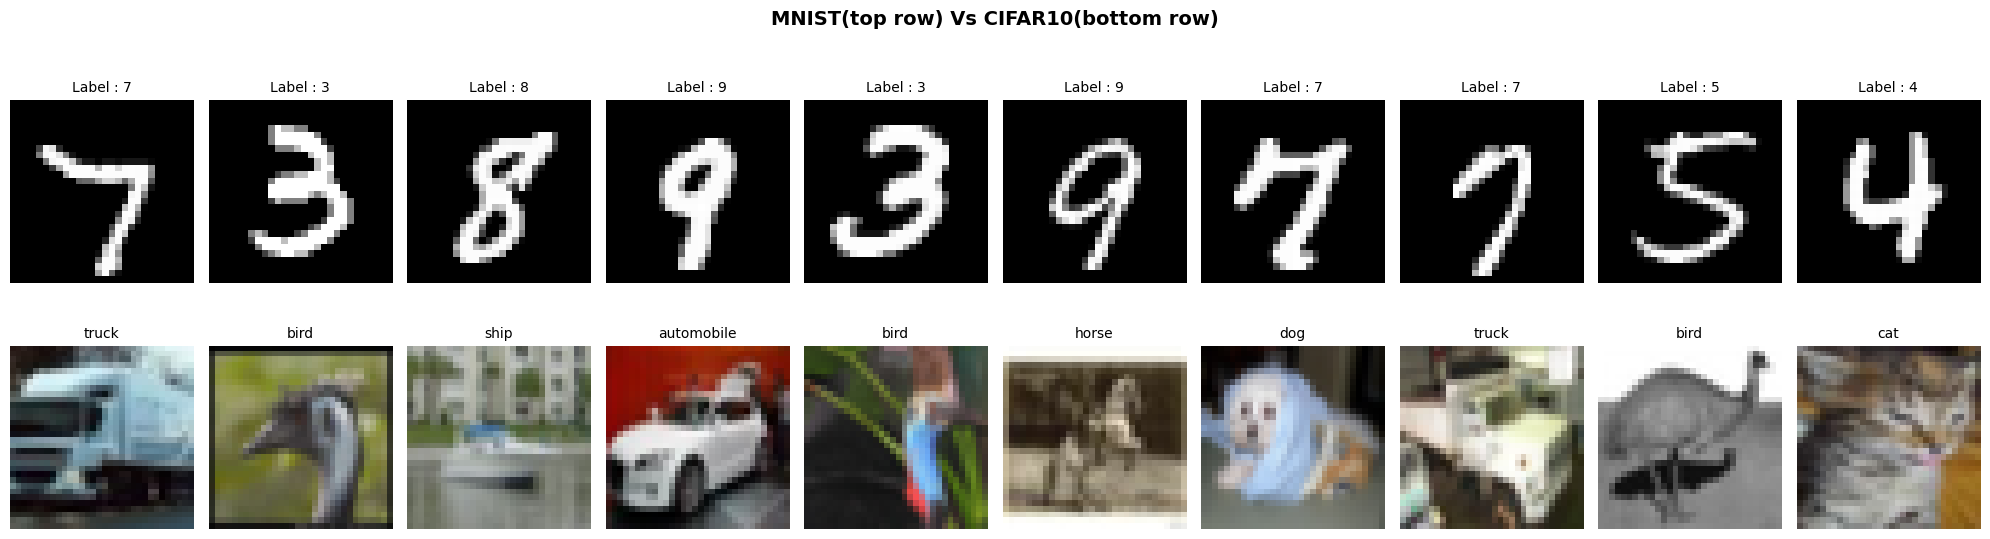

In [39]:
(mnist_train_x,mnist_train_y),(mnist_test_x,mnist_test_y) =  mnist.load_data()
(cifar10_train_x,cifar10_train_y),(cifar10_test_x,cifar10_test_y) =  cifar10.load_data()

# MNIST data set info
print(f'Info about MNIST data set:')
print(f'image train_shape: {mnist_train_x.shape}')
print(f'label train_shape: {mnist_train_y.shape}')
print(f'image test_shape: {mnist_test_x.shape}')
print(f'label test_shape: {mnist_test_y.shape}')
print (f"Pixel value range: [{int(mnist_train_x.min()),int(mnist_train_x.max())}]")

print("\n")

# CIFAR10 data set info
print(f'Info about CIFAR10 data set:')
print(f'image train_shape: {cifar10_train_x.shape}')
print(f'label train_shape: {cifar10_train_y.shape}')
print(f'image test_shape: {cifar10_test_x.shape}')
print(f'label test_shape: {cifar10_test_y.shape}')
print (f"Pixel value range: [{int(cifar10_train_x.min()),int(cifar10_train_x.max())}]")

# Checking the class balace of MNIST data
print("\nThe class balance of MNIST data set")
uni , cnt = np.unique(mnist_train_y,return_counts=True)
print(f'Class : {uni}')
print(f'Count : {cnt}')
print(f"The class is mostly well balanced except for digits as there are 60k samples in tarin data with 10 classes and all the classes have roughly 6k samples except for the class 1 and 5 ")

# Visualization of data
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig,axes = plt.subplots(2,10,figsize=(20,6))
fig.suptitle("MNIST(top row) Vs CIFAR10(bottom row)",fontsize=14,fontweight='bold')

# Random samples for MNIST data
mnist_ind = np.random.choice(len(mnist_train_x),10,replace=False)
for i,id in enumerate(mnist_ind):
  axes[0,i].imshow(mnist_train_x[id],cmap='gray')
  axes[0,i].set_title(f"Label : {mnist_train_y[id]}",fontsize=10)
  axes[0,i].axis("off")

# Random samples for CIFAR10 data
cifar_ind = np.random.choice(len(cifar10_train_x),10,replace=False)
for i,id in enumerate(cifar_ind):
  axes[1,i].imshow(cifar10_train_x[id])
  axes[1,i].set_title(cifar10_class_names[cifar10_train_y[id][0]],fontsize=10)
  axes[1,i].axis("off")

plt.tight_layout()
plt.savefig("Dataset_Sample.png",dpi=300)
plt.show()

## ***Preprocessing Pipeline***

In [40]:
def Preprocessing(imgs,labels,data_name="Dataset"):
  print(f"\n[{data_name}] before preprocessing:")
  print(f"Image shape: {imgs.shape},dtype: {imgs.dtype}")
  print(f"Label shape: {labels.shape},dtype: {labels.dtype}")
  print(f"Pixel range: [{int(imgs.min())},{int(imgs.max())}]")
  print(f"Sample labels: {labels[:5].flatten()}")

  imgs = imgs.astype(np.float32)/255.0

  if imgs.ndim==3:
    imgs = np.expand_dims(imgs,axis=-1)

  labels = labels.flatten()
  num_classes = 10
  one_hot = np.zeros((len(labels),num_classes),dtype=np.float32)
  one_hot[np.arange(len(labels)),labels] = 1.0

  print(f"\n[{data_name}] after preprocessing:")
  print(f"Image shape: {imgs.shape},dtype: {imgs.dtype}")
  print(f"Label shape: {one_hot.shape}")
  print(f"Pixel range: [{int(imgs.min()):.4f},{int(imgs.max()):.4f}]")
  print(f"Sample one hot labels: {one_hot[0]}")

  return imgs,one_hot

# Preprocessing of MNIST
mnist_tr_x_p,mnist_tr_y_p= Preprocessing(mnist_train_x,mnist_train_y,"MNIST train")
mnist_te_x_p,mnist_te_y_p= Preprocessing(mnist_test_x,mnist_test_y,"MNIST test")

# Preprocessing of CIFAR10
cifar10_tr_x_p,cifar10_tr_y_p= Preprocessing(cifar10_train_x,cifar10_train_y,"CIFAR10 train")
cifar10_te_x_p,cifar10_te_y_p= Preprocessing(cifar10_test_x,cifar10_test_y,"CIFAR10 test")



[MNIST train] before preprocessing:
Image shape: (60000, 28, 28),dtype: uint8
Label shape: (60000,),dtype: uint8
Pixel range: [0,255]
Sample labels: [5 0 4 1 9]

[MNIST train] after preprocessing:
Image shape: (60000, 28, 28, 1),dtype: float32
Label shape: (60000, 10)
Pixel range: [0.0000,1.0000]
Sample one hot labels: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

[MNIST test] before preprocessing:
Image shape: (10000, 28, 28),dtype: uint8
Label shape: (10000,),dtype: uint8
Pixel range: [0,255]
Sample labels: [7 2 1 0 4]

[MNIST test] after preprocessing:
Image shape: (10000, 28, 28, 1),dtype: float32
Label shape: (10000, 10)
Pixel range: [0.0000,1.0000]
Sample one hot labels: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

[CIFAR10 train] before preprocessing:
Image shape: (50000, 32, 32, 3),dtype: uint8
Label shape: (50000, 1),dtype: uint8
Pixel range: [0,255]
Sample labels: [6 9 9 4 1]

[CIFAR10 train] after preprocessing:
Image shape: (50000, 32, 32, 3),dtype: float32
Label shape: (50000, 10)
Pixel range: [0

## ***Data Augmentation Pipeline***

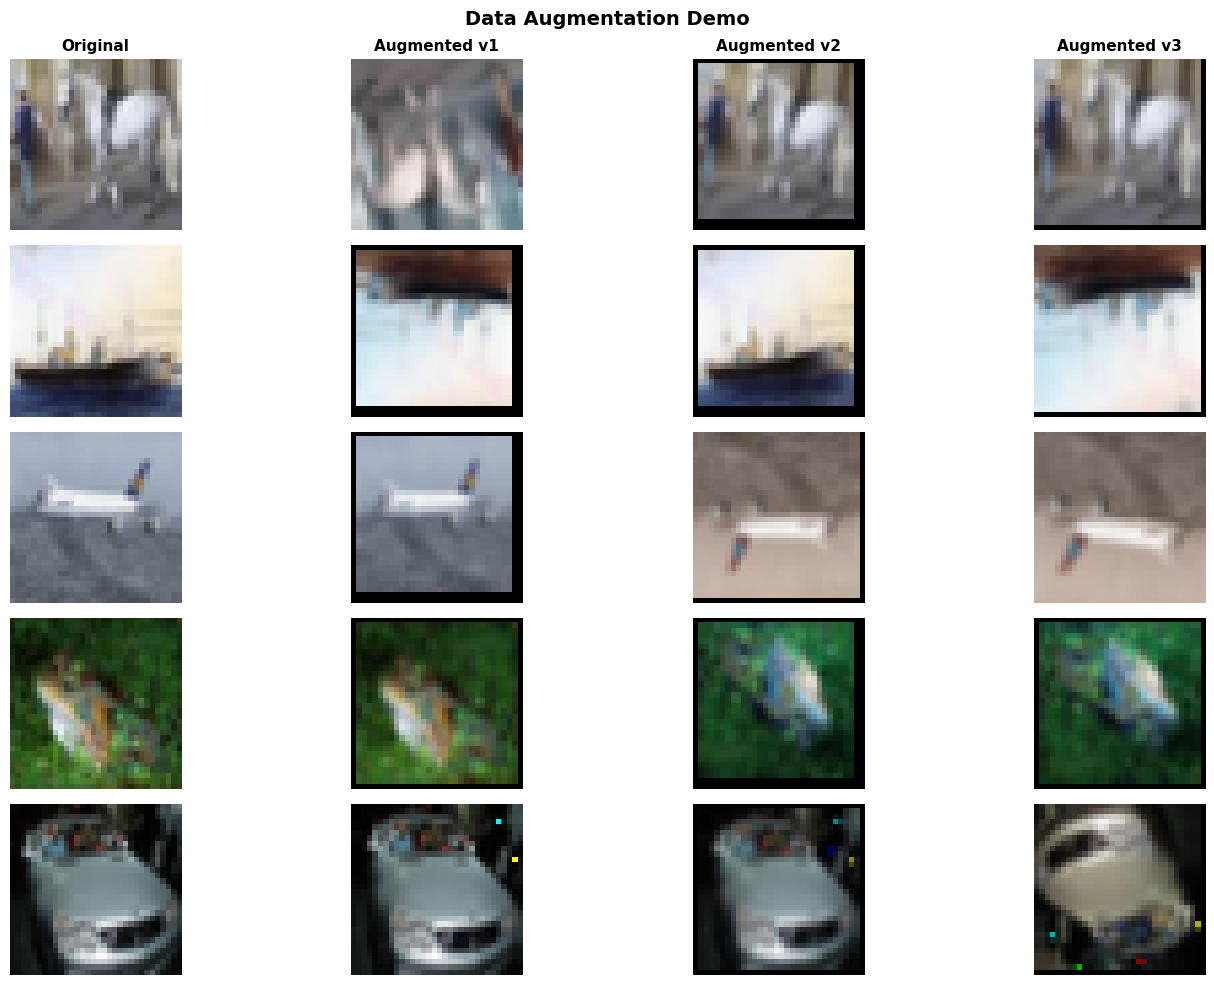

In [41]:
def aug_img(image):
  img = image.copy()
  if np.random.rand()<0.5:
    img = np.flip(img)

  angle = np.random.uniform(-10,10)
  img = scipy_rotate(img,angle,reshape=False,mode="nearest")

  zoom_fac = np.random.uniform(0.9,1.1)
  h,w = img.shape[:2]
  new_h = int(h*zoom_fac)
  new_w = int(w*zoom_fac)

  pil_img = PILImage.fromarray((img*255).astype(np.uint8))
  pil_img = pil_img.resize((new_w,new_h),PILImage.BILINEAR)
  img_resized = np.array(pil_img).astype(np.float32)/255.0

  if zoom_fac>1.0:
    st_h = (new_h-h)//2
    st_w = (new_w-w)//2
    img = img_resized[st_h:st_h+h,st_w:st_w+w]
  else:
    pad_h = (h-new_h)//2
    pad_w = (w-new_w)//2
    img = np.zeros_like(image)
    img[pad_h:pad_h+new_h,pad_w:pad_w+new_w] = img_resized

  return np.clip(img,0.0,1.0)

np.random.seed(42)
sample_ind = np.random.choice(len(cifar10_tr_x_p),5,replace=False)

fig,axes = plt.subplots(5,4,figsize=(15,10))
fig.suptitle("Data Augmentation Demo",fontsize=14,fontweight="bold")
col_labels = ["Original","Augmented v1","Augmented v2","Augmented v3"]

for col,label in enumerate(col_labels):
  axes[0,col].set_title(label,fontsize=11,fontweight="bold")

for r,id in enumerate(sample_ind):
  original = cifar10_tr_x_p[id]
  class_name = cifar10_class_names[cifar10_train_y[id][0]]
  axes[r,0].imshow(original)
  axes[r,0].set_ylabel(class_name,fontsize=10,rotation=0,labelpad=50)
  axes[r,0].axis("off")

  for c in range(1,4):
    aug = aug_img(original)
    axes[r,c].imshow(aug)
    axes[r,c].axis("off")

plt.tight_layout()
plt.savefig("augmentation_demo.png",dpi=300)
plt.show()

## ***Analysis Questions***

In [42]:
print("""
Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a greyscale image and an RGB image.
Ans--
The channel dimension C represents the number of independent signal types
at each spatial location.
For a grayscal image (C=1)
Each pixel has a single value representing brightness (0=black, 255=white).
Shape: (N, 28, 28, 1)

For an RGB image (C=3)
Each pixel has 3 values: how much Red, Green, and Blue light it emits.
Shape: (N, 32, 32, 3)
Example pixel: [255, 0, 0] = pure red.

In Conv2D, the kernel slides over (H, W) but sees ALL C channels at once,
computing a dot product across all three (or one) channel values together.


Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what data loading strategies would you use to avoid running out of memory?
Name at least two techniques and explain how each one helps.
Ans--
1. tf.data pipeline with on-the-fly loading:
   Instead of loading all images into RAM, read from disk one batch at a time.
   tf.data.Dataset.from_generator() + .prefetch() loads the next batch while
   the GPU is training on the current one → no memory bottleneck.

2. Image tiling / patch-based training:
   Divide each 1024×1024 image into 32×32 or 64×64 tiles. Train on tiles.
   This reduces each input to CNN-manageable sizes without losing detail.
   At inference, reassemble predictions from tiles using sliding window.


Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation computed from the test set itself.
What is wrong with this approach?
Ans--
In production, when a new image arrives, you don't know its statistics
you just have the image. The model was trained expecting inputs normalised
by the training set's mean/std. If test normalisation uses different values,
the distribution shifts and the model gets unexpected inputs.

Correct approach is to compute mean and std of training set only,
then apply the same values to both validation and test sets.
""")


Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a greyscale image and an RGB image.
Ans--
The channel dimension C represents the number of independent signal types 
at each spatial location.
For a grayscal image (C=1)
Each pixel has a single value representing brightness (0=black, 255=white).
Shape: (N, 28, 28, 1)

For an RGB image (C=3)
Each pixel has 3 values: how much Red, Green, and Blue light it emits.
Shape: (N, 32, 32, 3)
Example pixel: [255, 0, 0] = pure red.

In Conv2D, the kernel slides over (H, W) but sees ALL C channels at once,
computing a dot product across all three (or one) channel values together.


Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what data loading strategies would you use to avoid running out of memory?
Name at least two techniques and explain how each one helps.
Ans--
1. tf.data pipeline with on-the-fly loading:
   Instead of loading all im

# ***Building a CNN from Scratch (Task - 2)***

## ***Manual 2D Convolution(Numpy only)***

In [43]:
def conv2d(img,kernel,stride=1,padding=0):
  h,w = img.shape
  kh,kw = kernel.shape

  if padding>0:
    img = np.pad(img,padding,mode="constant",constant_values=0)
    h_pad,w_pad=img.shape
  else:
    h_pad,w_pad=h,w

  out_h = (h_pad-kh)//stride+1
  out_w = (w_pad-kw)//stride+1

  feature_map = np.zeros((out_h,out_w),dtype=np.float64)

  for i in range(out_h):
    for j in range(out_w):
      row_st = i*stride
      col_st = j*stride
      patch = img[row_st:row_st+kh,col_st:col_st+kw]
      feature_map[i,j] = np.sum(patch*kernel)

  return feature_map



# Testing given a 5X5 img with sobel-X kernel
test_img = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
],dtype=np.float64)
sobel_x = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
],dtype=np.float64)

res = conv2d(test_img,sobel_x,stride=1,padding=0)

print(f"Input image:")
print(test_img.astype(int))
print(f"Sobel-X kernel:")
print(sobel_x.astype(int))
print(f"Convolution Output Iamge:")
print(res)
print(f"\nOutput shape:{res.shape}")
print(f"Expected shape using formula: ({(5-3)//1 + 1},{(5-3)//1 + 1})")
print(f"Interpretation:\nPositive values- left to right bright inc\nNegtaive values- right to left brightness dec")




Input image:
[[3 1 0 2 4]
 [1 5 3 2 1]
 [0 2 6 4 3]
 [2 3 1 5 2]
 [1 0 2 3 4]]
Sobel-X kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Convolution Output Iamge:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape:(3, 3)
Expected shape using formula: (3,3)
Interpretation:
Positive values- left to right bright inc
Negtaive values- right to left brightness dec


## ***Output Size Derivation***

In [44]:
def calc_output_size(input_size,kernel,padding,stride):
  output = (input_size-kernel+2*padding)/stride+1
  return int(output)

print("""
formula: Output = floor((Input-kernel + 2 x padding)/stride)+1

a) input=28, kernel=5, padding=0,stride=1
          = floor((28-5+2x0)/1)+1
          = floor(23/1)+1
          = 24
   output = 24x24""")
print(f"   verified:{calc_output_size(28,5,0,1)}x{calc_output_size(28,5,0,1)}")
print("""
b) input=28, kernel=3, padding=0,stride=1
          = floor((28-3+2x1)/1)+1
          = floor(27/1)+1
          = 28
   output = 28x28 same after padding
   Therefore padding keeps spatial size identical.""")
print(f"   verified:{calc_output_size(28,3,1,1)}x{calc_output_size(28,3,1,1)}")

print("""
c) input=32, kernel=3, padding=0,stride=2
          = floor((32-3+2x0)/2)+1
          = floor(29/2)+1
          = 15
   output = 15x15
   stride=2 halves the spatial size.""")
print(f"   verified:{calc_output_size(32,3,0,2)}x{calc_output_size(32,3,0,2)}")

step1=calc_output_size(32,3,1,1)
step2=calc_output_size(step1,3,0,1)
print("""
d) Two consecutive layers on 32x32:
   Layer 1: Input=32,K=3,P=1,S=1
   = floor((32-3+2x1)/1)+1 = 32
   Output = 32x32 (same padding preserves size)
   Layer 2: Input=32,K=3,P=0,S=1
   = floor((32-3+2x0)/1)+1 = 30
   Final Output = 30x30""")
print(f"   verified:{step1}X{step1} -> {step2}X{step2}")


formula: Output = floor((Input-kernel + 2 x padding)/stride)+1

a) input=28, kernel=5, padding=0,stride=1
          = floor((28-5+2x0)/1)+1
          = floor(23/1)+1
          = 24
   output = 24x24
   verified:24x24

b) input=28, kernel=3, padding=0,stride=1
          = floor((28-3+2x1)/1)+1
          = floor(27/1)+1
          = 28
   output = 28x28 same after padding
   Therefore padding keeps spatial size identical.
   verified:28x28

c) input=32, kernel=3, padding=0,stride=2
          = floor((32-3+2x0)/2)+1
          = floor(29/2)+1          
          = 15
   output = 15x15 
   stride=2 halves the spatial size.
   verified:15x15

d) Two consecutive layers on 32x32:
   Layer 1: Input=32,K=3,P=1,S=1
   = floor((32-3+2x1)/1)+1 = 32
   Output = 32x32 (same padding preserves size)
   Layer 2: Input=32,K=3,P=0,S=1
   = floor((32-3+2x0)/1)+1 = 30
   Final Output = 30x30
   verified:32X32 -> 30X30


## ***Impement LeNet-5***

In [45]:
def build_lenet5(input_shape=(28,28,1),num_classes=10):
  model = models.Sequential([
      layers.Input(shape=input_shape),
      layers.Conv2D(6,(5,5),padding="valid",name="conv1"),
      layers.Activation("tanh",name="tanh1"),
      layers.AveragePooling2D(pool_size=(2,2),name="avgpool1",strides=2),
      layers.Conv2D(16,(5,5),padding="valid",name="conv2"),
      layers.Activation("tanh",name="tanh2"),
      layers.AveragePooling2D(pool_size=(2,2),name="avgpool2",strides=2),
      layers.Flatten(name="flatten"),
      layers.Dense(120,name="dense1"),
      layers.Activation("tanh",name="tanh3"),
      layers.Dense(84,name="dense2"),
      layers.Activation("tanh",name="tanh4"),
      layers.Dense(num_classes,activation="softmax",name="output")
  ])
  return model

lenet = build_lenet5()
print(f"LeNet-5 Architecture Summary:")
lenet.summary()
print(f"\nManual Parameter Count Conv1(6filters,5x5,c_in=1)")
print(f"Formula: (kernel_h x kernel_w x c_in + 1_bias) x c_out")
k,c_in,c_out = 5,1,6
params_conv1 = (k*k*c_in+1)*c_out
print(f" = (5x5x1 + 1) x 6 = (25+1) = {params_conv1}")

total_params = sum(np.prod(v.shape)for v in lenet.trainable_variables)
print(f"\nTotal trainable parameters(from summary): {total_params}")

LeNet-5 Architecture Summary:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tanh1 (Activation)              │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling2D)     │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tanh2 (Activation)              │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling2D)     │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tanh3 (Activation)              │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tanh4 (Activation)              │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Manual Parameter Count Conv1(6filters,5x5,c_in=1)
Formula: (kernel_h x kernel_w x c_in + 1_bias) x c_out
 = (5x5x1 + 1) x 6 = (25+1) = 156

Total trainable parameters(from summary): 44426


## ***Design a Custom CNN for CIFAR-10***

In [46]:
def custom_cnn(input_shape=(32,32,3),num_classes=10):
  model = models.Sequential([
      layers.Input(shape=input_shape),
      layers.Conv2D(32,(3,3),padding="same",name="conv1"),
      layers.BatchNormalization(name="bn1"),
      layers.Activation("relu",name="relu1"),
      layers.MaxPooling2D((2,2),name="pool1"),
      layers.Dropout(0.25,name="drop1"),
      layers.Conv2D(64,(3,3),padding="same",name="conv2_1"),
      layers.BatchNormalization(name="bn2"),
      layers.Activation("relu",name="relu2"),
      layers.MaxPooling2D((2,2),name="pool2"),
      layers.Dropout(0.25,name="drop2"),
      layers.Conv2D(128,(3,3),padding="same",name="conv3_1"),
      layers.BatchNormalization(name="bn3"),
      layers.Activation("relu",name="relu3"),
      layers.MaxPooling2D((2,2),name="pool3"),
      layers.Dropout(0.25,name="drop3"),
      layers.GlobalAveragePooling2D(name="gap"),
      layers.Dense(256,name="dense1"),
      layers.Activation("relu",name="relu_dense"),
      layers.Dropout(0.5,name="drop_head"),
      layers.Dense(num_classes,activation="softmax",name="output"),
  ])

  return model


cnn = custom_cnn()
print(f"Custom CNN Architecture Summary:")
cnn.summary()

total = sum(np.prod(v.shape) for v in cnn.trainable_variables)
print(f"\nTotal parameters: {total}")

Custom CNN Architecture Summary:


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_head (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 129290


## ***Analysis Questions***

In [47]:
print("""
Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters.
Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.
Ans--
Stacking two 3×3 layers gives you the exact same 5×5 field of vision but allows you to sandwich an extra ReLU activation in between.
This extra non-linearity makes your network more expressive and capable of modeling complex functions,due to which deep architectures
like VGG and ResNet rely heavily on 3×3 convolutions.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or after activation), and why?
Mention at least two empirical benefits it provides during training.
Ans--
Batch Norm acts as a stabilizer for your network. It takes the outputs of a layer and normalizes them across the mini-batch so
they have a mean near 0 and a variance near 1.
Placement is typically Conv->Batch Norm->Activation (ReLU).
The benefist are:
1. It minimizes internal covariate shift.
2. Calculating statistics on random mini-batches injects a small noise into the network, which helps to prevent overfitting.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do geometrically?
What would happen to the parameter count and spatial information if you replaced it with Flatten?
Ans--
Geometry & parameters: Flatten converts the 3D feature map into a massive 1D vector, while GAP averages each channel into a single value,
slashing parameter counts to prevent overfitting.
Information Trade-off: GAP discards spatial information, focusing only on the presence of features, making it ideal for classification
but less effective for tasks requiring precise object localization.
""")


Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters.
Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.
Ans--
Stacking two 3×3 layers gives you the exact same 5×5 field of vision but allows you to sandwich an extra ReLU activation in between.
This extra non-linearity makes your network more expressive and capable of modeling complex functions,due to which deep architectures 
like VGG and ResNet rely heavily on 3×3 convolutions.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or after activation), and why?
Mention at least two empirical benefits it provides during training.
Ans--
Batch Norm acts as a stabilizer for your network. It takes the outputs of a layer and normalizes them across the mini-batch so 
they have a mean near 0 and a variance near 1.
Placement is typically

# ***Training, Tuning & Regularisation (Task - 3)***

## ***FIRST TRAINING RUN (LeNet-5 on MNIST with SGD)***

Loading the datasets...
Loaded the dataset
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7811 - loss: 0.8792 - val_accuracy: 0.9080 - val_loss: 0.3683
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8960 - loss: 0.3766 - val_accuracy: 0.9267 - val_loss: 0.2717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9128 - loss: 0.3041 - val_accuracy: 0.9362 - val_loss: 0.2281
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9248 - loss: 0.2609 - val_accuracy: 0.9442 - val_loss: 0.1983
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9335 - loss: 0.2286 - val_accuracy: 0.9513 - val_loss: 0.1751
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9404 - loss: 0.2026 - val_accuracy: 0.9583 - val_loss: 0.1565
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9470 - loss: 0.1812 - val_accuracy: 0.9618 - val_loss: 0.1413
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accurac

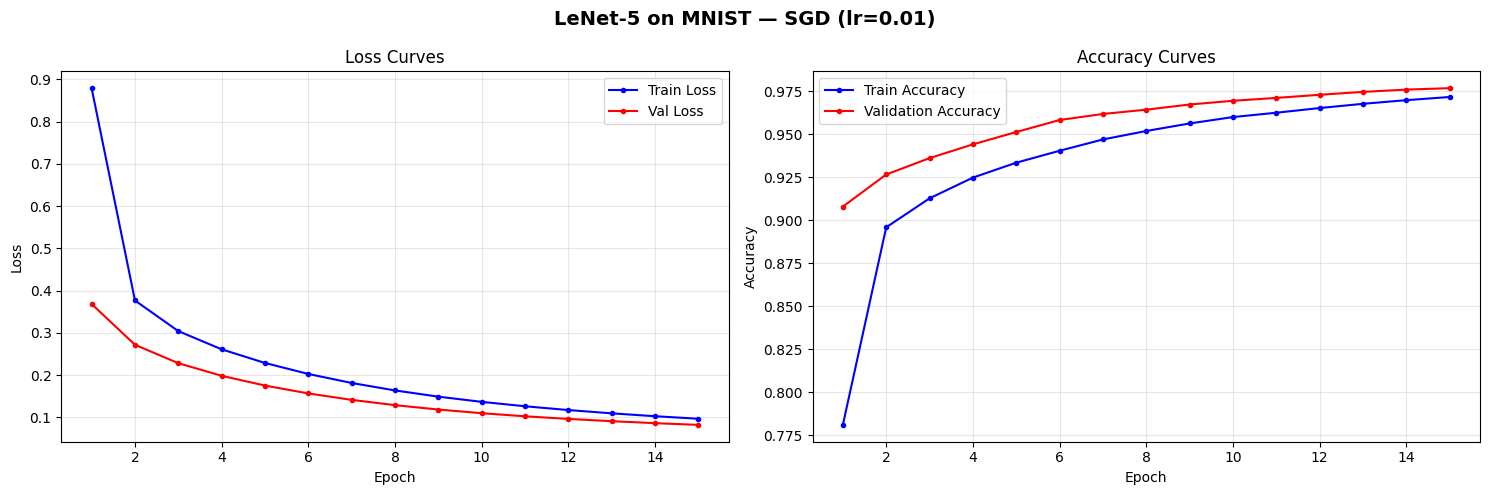

In [48]:
from enum import verify
from tensorflow._api.v2.config import optimizer
def load_and_preprocess():
  (mx_tr,my_tr),(mx_te, my_te) = mnist.load_data()
  (cx_tr,cy_tr),(cx_te, cy_te) = cifar10.load_data()
  mx_tr = mx_tr.astype(np.float32) / 255.0
  mx_te = mx_te.astype(np.float32) / 255.0
  cx_tr = cx_tr.astype(np.float32) / 255.0
  cx_te = cx_te.astype(np.float32) / 255.0
  mx_tr = np.expand_dims(mx_tr, -1)
  mx_te = np.expand_dims(mx_te, -1)
  my_tr = keras.utils.to_categorical(my_tr, 10)
  my_te = keras.utils.to_categorical(my_te, 10)
  cy_tr = keras.utils.to_categorical(cy_tr, 10)
  cy_te = keras.utils.to_categorical(cy_te, 10)

  return (mx_tr, my_tr, mx_te, my_te), (cx_tr, cy_tr, cx_te, cy_te)

print(f"Loading the datasets...")
(mnist_train_x, mnist_train_y, mnist_test_x, mnist_test_y), \
(cifar10_train_x, cifar10_train_y, cifar10_test_x, cifar10_test_y) = load_and_preprocess()
print(f"Loaded the dataset")

def build_cifar_cnn(dropout=True, batchnorm=True):
  model = models.Sequential(name=f"cifar_do{int(dropout)}_bn{int(batchnorm)}")
  model.add(layers.Input(shape=(32, 32, 3)))
  model.add(layers.Conv2D(32, (3,3), padding='same'))
  if batchnorm: model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D((2,2)))
  if dropout:  model.add(layers.Dropout(0.25))
  model.add(layers.Conv2D(64, (3,3), padding='same'))
  if batchnorm: model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D((2,2)))
  if dropout:  model.add(layers.Dropout(0.25))
  model.add(layers.Conv2D(128, (3,3), padding='same'))
  if batchnorm: model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D((2,2)))
  if dropout:  model.add(layers.Dropout(0.25))
  model.add(layers.GlobalAveragePooling2D())
  model.add(layers.Dense(256, activation='relu'))
  if dropout:  model.add(layers.Dropout(0.5))
  model.add(layers.Dense(10, activation='softmax'))

  return model

def plot_history(history, title, save_path):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
  fig.suptitle(title, fontsize=14, fontweight='bold')
  epochs = range(1, len(history['loss']) + 1)
  ax1.plot(epochs, history['loss'],     'b-o', markersize=3, label='Train Loss')
  ax1.plot(epochs, history['val_loss'], 'r-o', markersize=3, label='Val Loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Loss')
  ax1.set_title('Loss Curves')
  ax1.legend()
  ax1.grid(True, alpha=0.3)
  ax2.plot(epochs, history['accuracy'],"b-o", markersize=3, label='Train Accuracy')
  ax2.plot(epochs, history['val_accuracy'],"r-o", markersize=3, label='Validation Accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.set_title('Accuracy Curves')
  ax2.legend()
  ax2.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(save_path, dpi=300)
  plt.show()

model_p1 = build_lenet5()
model_p1.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),loss="categorical_crossentropy",metrics=["accuracy"])

history_p1 = model_p1.fit(mnist_train_x,mnist_train_y,epochs=15,batch_size=64,validation_split=0.1,verbose=1)

test_loss,test_acc = model_p1.evaluate(mnist_test_x,mnist_test_y,verbose=0)
print(f"Test accuarcy: {test_acc:.4f}")

val_losses = history_p1.history['val_loss']
overfit_epoch = None
for i in range(1, len(val_losses) - 1):
    if val_losses[i] > val_losses[i-1] and val_losses[i+1] > val_losses[i]:
        overfit_epoch = i + 1
        break

if overfit_epoch:
    print(f"Overfitting first observed at epoch {overfit_epoch}")
    print(f"Valdation loss at epoch {overfit_epoch-1}: {val_losses[overfit_epoch-2]:.4f}")
    print(f"Validation loss at epoch {overfit_epoch}: {val_losses[overfit_epoch-1]:.4f}")
else:
    print("No clear overfitting detected in 15 epochs.")

plot_history(history_p1.history, "LeNet-5 on MNIST — SGD (lr=0.01)", "lenet_sgd_curves.png")

## ***OPTIMISER COMPARISON***

Training with: SGD (lr=0.01)
Final validation accuracy: 0.9798
Training with: SGD + Momentum (lr=0.01, m=0.9)
Final validation accuracy: 0.9885
Training with: Adam (lr=0.001)
Final validation accuracy: 0.9863


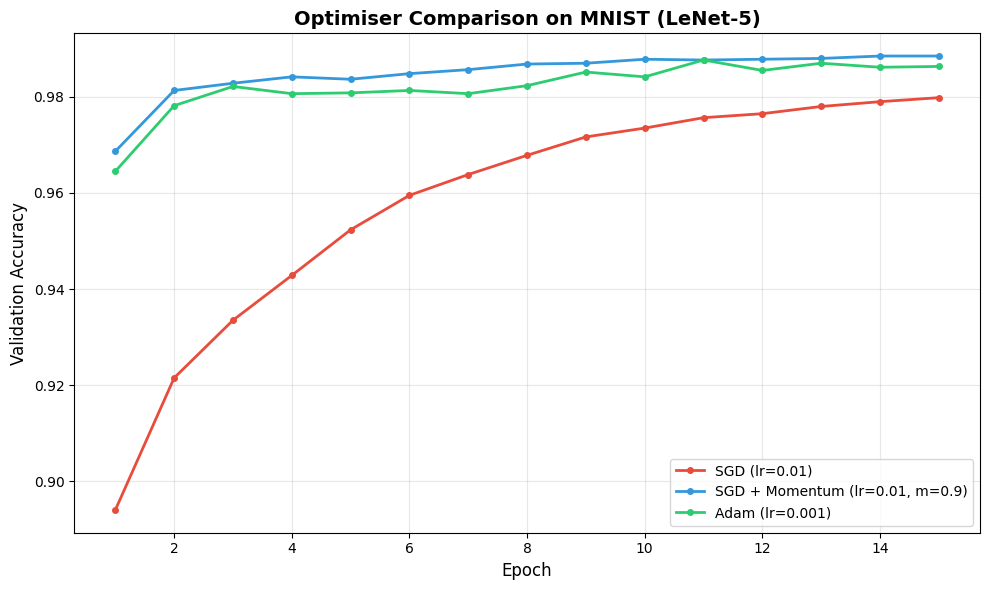

In [49]:
optimisers = {
  'SGD (lr=0.01)':keras.optimizers.SGD(learning_rate=0.01),
  'SGD + Momentum (lr=0.01, m=0.9)':keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
  'Adam (lr=0.001)':keras.optimizers.Adam(learning_rate=0.001),
}
hist_opt = {}
for name, opt in optimisers.items():
  print(f"Training with: {name}")
  np.random.seed(42)
  tf.random.set_seed(42)
  m = build_lenet5()
  m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  h = m.fit(
      mnist_train_x, mnist_train_y,
      epochs=15, batch_size=64,
      validation_split=0.1,
      verbose=0
    )
  hist_opt[name] = h.history
  print(f"Final validation accuracy: {h.history['val_accuracy'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (name, hist), color in zip(hist_opt.items(), colors):
    ax.plot(range(1, 16), hist['val_accuracy'], '-o', markersize=4,
            label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Optimiser Comparison on MNIST (LeNet-5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=300)
plt.show()

## ***LEARNING RATE & BATCH SIZE GRID SEARCH***

In [50]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes    = [32, 128]
results_grid   = {}

for lr in learning_rates:
  for bs in batch_sizes:
      print(f"Training: lr={lr}, batch_size={bs}")
      np.random.seed(42)
      tf.random.set_seed(42)
      m = build_cifar_cnn(dropout=True, batchnorm=True)
      m.compile(
          optimizer=keras.optimizers.Adam(learning_rate=lr),
          loss='categorical_crossentropy',
          metrics=['accuracy']
      )
      h = m.fit(
        cifar10_train_x, cifar10_train_y,
        epochs=10,
        batch_size=bs,
        validation_split=0.1,
        verbose=0
      )
      val_acc = h.history['val_accuracy'][-1]
      results_grid[(lr, bs)] = val_acc
      print(f"Validation accuracy: {val_acc:.4f}")

print("\nGrid Search Results Table:")
print(f"{'LR/Batch':>10} | {'BS=32':>8} | {'BS=128':>8}")
best_combo = max(results_grid, key=results_grid.get)
for lr in learning_rates:
    row = f"{lr:>10} | "
    for bs in batch_sizes:
        v = results_grid[(lr, bs)]
        marker = " ★" if (lr, bs) == best_combo else ""
        row += f"{v:.4f}{marker:>3} | "
    print(row)
print(f"\nBest combination: lr={best_combo[0]}, batch_size={best_combo[1]}: {results_grid[best_combo]:.4f}")

Training: lr=0.1, batch_size=32
Validation accuracy: 0.0970
Training: lr=0.1, batch_size=128
Validation accuracy: 0.0970
Training: lr=0.01, batch_size=32
Validation accuracy: 0.5692
Training: lr=0.01, batch_size=128
Validation accuracy: 0.6958
Training: lr=0.001, batch_size=32
Validation accuracy: 0.6516
Training: lr=0.001, batch_size=128
Validation accuracy: 0.5540

Grid Search Results Table:
  LR/Batch |    BS=32 |   BS=128
       0.1 | 0.0970    | 0.0970    | 
      0.01 | 0.5692    | 0.6958  ★ | 
     0.001 | 0.6516    | 0.5540    | 

Best combination: lr=0.01, batch_size=128: 0.6958


## ***REGULARISATION EXPERIMENT***


Training: No Regularisation
Train accuracy: 0.8300 | Val acc: 0.7322 | Gap: 0.0978

Training: Dropout Only
Train accuracy: 0.7034 | Val acc: 0.7396 | Gap: -0.0362

Training: BatchNorm Only
Train accuracy: 0.9066 | Val acc: 0.6172 | Gap: 0.2894

Training: Dropout + BatchNorm
Train accuracy: 0.7156 | Val acc: 0.7274 | Gap: -0.0118


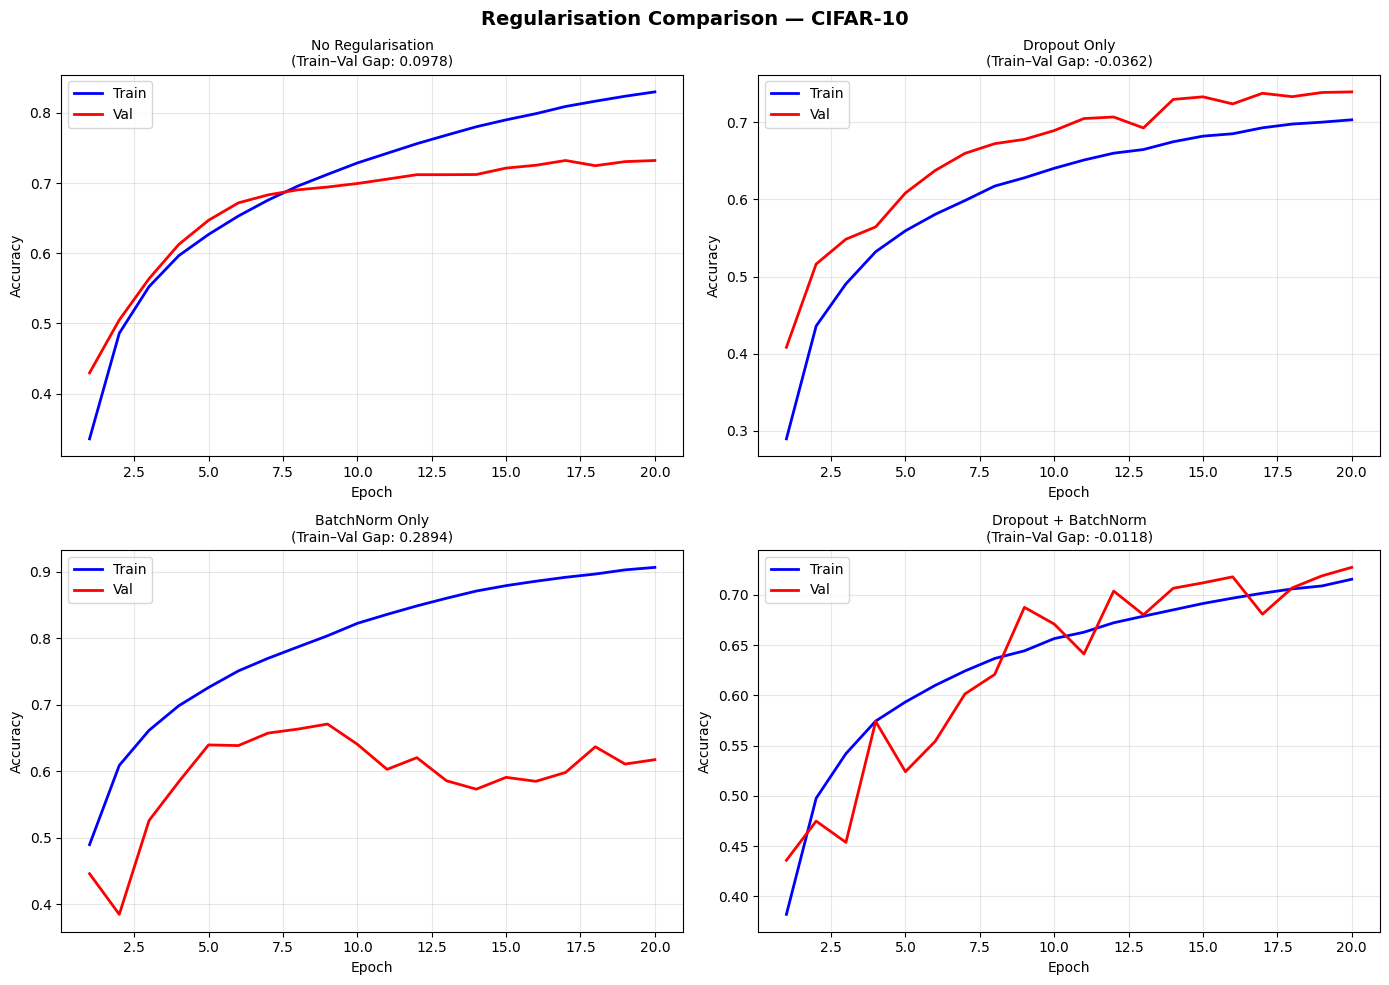


Regularisation Summary Table
Variant                   | Train Acc |  Val Acc |      Gap
No Regularisation         |    0.8300 |   0.7322 |   0.0978
Dropout Only              |    0.7034 |   0.7396 |  -0.0362
BatchNorm Only            |    0.9066 |   0.6172 |   0.2894
Dropout + BatchNorm       |    0.7156 |   0.7274 |  -0.0118


In [51]:
variants = {
  'No Regularisation':build_cifar_cnn(dropout=False, batchnorm=False),
  'Dropout Only':build_cifar_cnn(dropout=True,  batchnorm=False),
  'BatchNorm Only':build_cifar_cnn(dropout=False, batchnorm=True),
  'Dropout + BatchNorm':build_cifar_cnn(dropout=True,  batchnorm=True),
}

hist_reg = {}
for name, model in variants.items():
    print(f"\nTraining: {name}")
    np.random.seed(42)
    tf.random.set_seed(42)
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        cifar10_train_x,cifar10_train_y,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )
    hist_reg[name] = h.history
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    print(f"Train accuracy: {train_acc:.4f} | Val acc: {val_acc:.4f} | Gap: {gap:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regularisation Comparison — CIFAR-10',fontsize=14,fontweight='bold')

for ax, (name, hist) in zip(axes.flatten(), hist_reg.items()):
  eps = range(1, len(hist['accuracy']) + 1)
  ax.plot(eps,hist['accuracy'],'b-',label='Train',linewidth=2)
  ax.plot(eps,hist['val_accuracy'],'r-',label='Val',linewidth=2)
  gap = hist['accuracy'][-1] - hist['val_accuracy'][-1]
  ax.set_title(f'{name}\n(Train–Val Gap: {gap:.4f})', fontsize=10)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Accuracy')
  ax.legend()
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularisation_comparison.png', dpi=300)
plt.show()

print("\nRegularisation Summary Table")
print(f"{'Variant':<25} | {'Train Acc':>9} | {'Val Acc':>8} | {'Gap':>8}")
for name, hist in hist_reg.items():
  tr = hist['accuracy'][-1]
  va = hist['val_accuracy'][-1]
  print(f"{name:<25} | {tr:>9.4f} | {va:>8.4f} | {tr-va:>8.4f}")

Training with ReduceLROnPlateau

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Training with Cosine Annealing


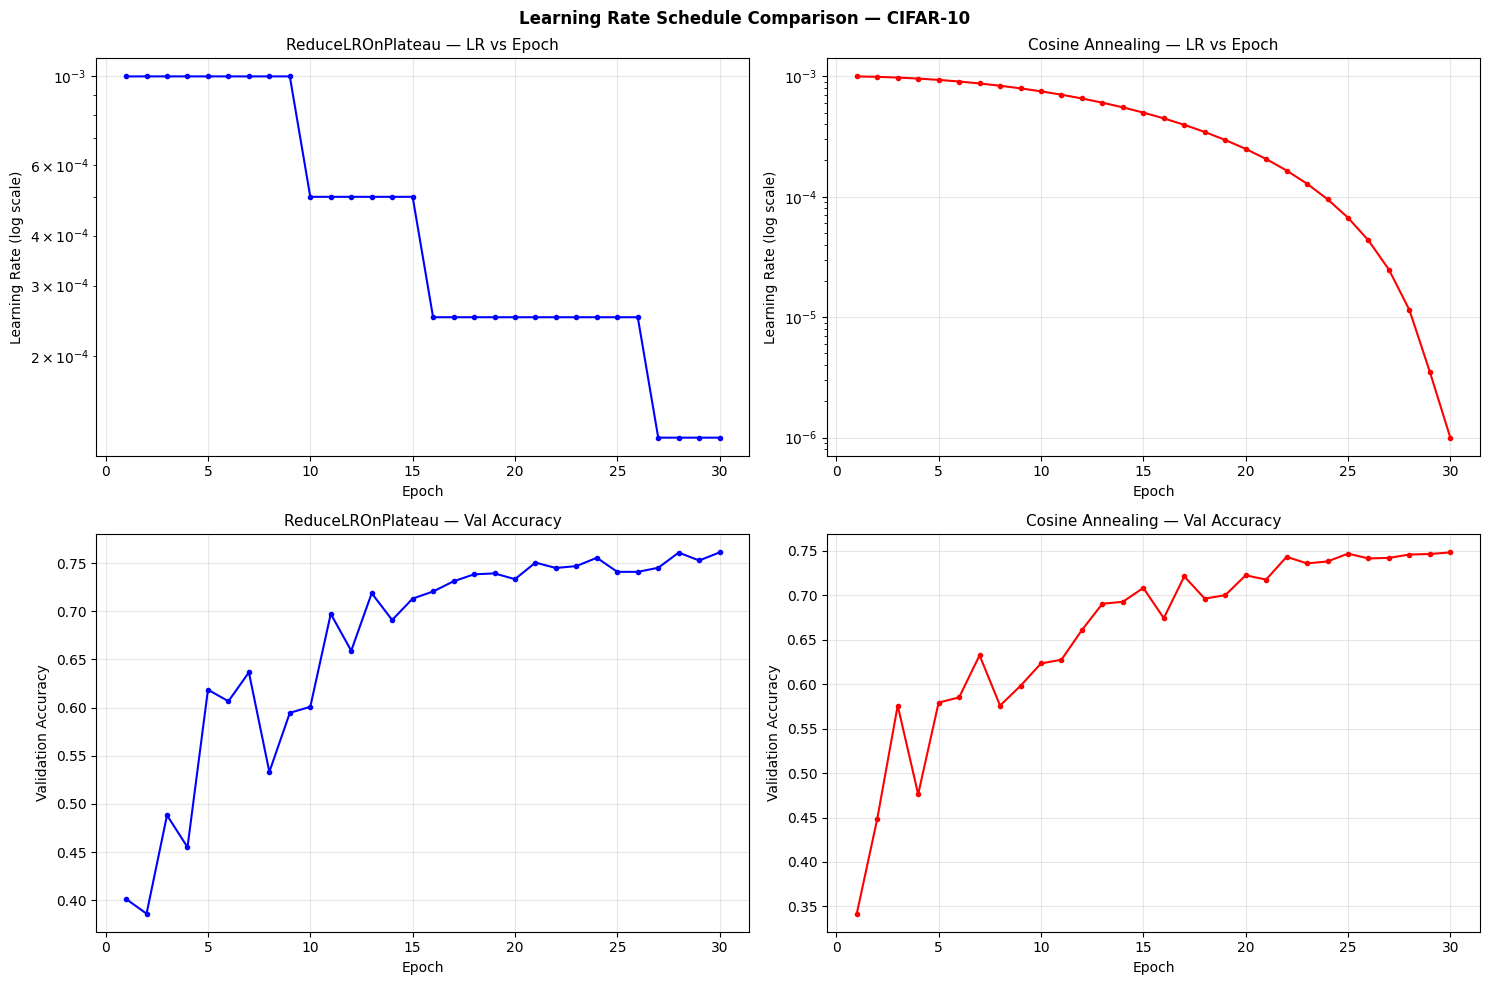


Best val accuracy — ReduceLROnPlateau: 0.7612
Best val accuracy — Cosine Annealing:  0.7484


In [52]:
EPOCHS = 30
INIT_LR = 0.001

print("Training with ReduceLROnPlateau")
np.random.seed(42); tf.random.set_seed(42)
model_plateau = build_cifar_cnn(dropout=True, batchnorm=True)
model_plateau.compile(
  optimizer=keras.optimizers.Adam(INIT_LR),
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

lr_tracker_plateau = []
class LRLogger(callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
      lr_tracker_plateau.append(float(self.model.optimizer.learning_rate))

h_plateau = model_plateau.fit(
  cifar10_train_x, cifar10_train_y,
  epochs=EPOCHS, batch_size=64,
  validation_split=0.1,
  callbacks=[
      callbacks.ReduceLROnPlateau(
          monitor='val_loss', factor=0.5, patience=3,
          min_lr=1e-6, verbose=1
      ),
      LRLogger()
  ],
  verbose=0)
print("\nTraining with Cosine Annealing")
np.random.seed(42); tf.random.set_seed(42)

cosine_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INIT_LR,
    decay_steps=EPOCHS * (len(cifar10_train_x) * 0.9 // 64),
    alpha=1e-6/INIT_LR
)

model_cosine = build_cifar_cnn(dropout=True, batchnorm=True)
model_cosine.compile(
  optimizer=keras.optimizers.Adam(cosine_schedule),
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

lr_tracker_cosine = []
class LRLoggerCosine(callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
      opt = self.model.optimizer
      if hasattr(opt.learning_rate, '__call__'):
          step = opt.iterations.numpy()
          lr = float(opt.learning_rate(step))
      else:
          lr = float(opt.learning_rate)
      lr_tracker_cosine.append(lr)

h_cosine = model_cosine.fit(
  cifar10_train_x, cifar10_train_y,
  epochs=EPOCHS, batch_size=64,
  validation_split=0.1,
  callbacks=[LRLoggerCosine()],
  verbose=0
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Learning Rate Schedule Comparison — CIFAR-10', fontsize=12, fontweight='bold')
eps = range(1, EPOCHS + 1)

axes[0,0].semilogy(eps, lr_tracker_plateau[:EPOCHS],'b-o', markersize=3)
axes[0,0].set_title('ReduceLROnPlateau — LR vs Epoch', fontsize=11)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Learning Rate (log scale)')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].semilogy(eps, lr_tracker_cosine[:EPOCHS],'r-o', markersize=3)
axes[0,1].set_title('Cosine Annealing — LR vs Epoch', fontsize=11)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Learning Rate (log scale)')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(eps, h_plateau.history['val_accuracy'][:EPOCHS], 'b-o', markersize=3)
axes[1,0].set_title('ReduceLROnPlateau — Val Accuracy', fontsize=11)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Validation Accuracy')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, h_cosine.history['val_accuracy'][:EPOCHS], 'r-o', markersize=3)
axes[1,1].set_title('Cosine Annealing — Val Accuracy', fontsize=11)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Validation Accuracy')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=300)
plt.show()
best_plateau = max(h_plateau.history['val_accuracy'])
best_cosine  = max(h_cosine.history['val_accuracy'])
print(f"\nBest val accuracy — ReduceLROnPlateau: {best_plateau:.4f}")
print(f"Best val accuracy — Cosine Annealing:  {best_cosine:.4f}")


## ***Analysis Questions***

In [54]:
print("""
Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge.
Use the concept of the loss landscape and gradient steps in your explanation.
Ans--
Normal learning rate: Takes small, steady steps to gently converge at the minimum.
Too high learning rate (e.g., lr=1.0): Takes massive steps that completely overshoot the valley. Instead of settling at the bottom, the loss bounces back and forth (oscillates) or diverges entirely.
The Math: Because updates are calculated as weight_new = weight - (lr * gradient),
a high learning rate multiplies the gradient too much. This throws the model into completely wrong weight spaces, which is dangerous in narrow valleys or saddle points.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best accuracies.
From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed.
Ans--
Small Batch + Low LR (Optimal): Small batches introduce gradient noise, allowing the optimizer to escape sharp local minima and find flatter,regions that generalize better.
A low learning rate ensures these updates remain stable.
Large Batch + High LR (Suboptimal): Large batches provide smooth, accurate gradients that can trap the model in narrow, sharp minima which perform poorly on new data.
A high learning rate significantly increases the risk of overshooting the optimal solution entirely.

Q3. Dropout is disabled at inference (test) time. Why?
If a network has Dropout(0.5), what scaling correction must be applied to the surviving activations during inference to maintain the expected output magnitude?
Ans--
Deployed models need deterministic predictions. Leaving Dropout on would yield random, inconsistent outputs for the exact same input every time you run it.
Because 100% of neurons fire during inference (compared to 50% during training with a 0.5 rate), the total output magnitude doubles.
To compensate, test-time activations must be multiplied by (1 - rate), which is 0.5.

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii) the shape of the LR curve,
and (iii) which scenario each is better suited for.
Ans--
ReduceLROnPlateau is a reactive scheduler that drops the learning rate in a sharp "staircase" pattern only when the validation loss plateaus. It is ideal where the training dynamics are unknown.
In contrast, Cosine Annealing is proactive, continuously decaying the learning rate along a smooth S-curve based on a fixed schedule. It is best for fine-tuning where the total number of epochs is known and you need to get the maximum final performance.
""")


Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge.
Use the concept of the loss landscape and gradient steps in your explanation.
Ans--
Normal learning rate: Takes small, steady steps to gently converge at the minimum.
Too high learning rate (e.g., lr=1.0): Takes massive steps that completely overshoot the valley. Instead of settling at the bottom, the loss bounces back and forth (oscillates) or diverges entirely.
The Math: Because updates are calculated as weight_new = weight - (lr * gradient), 
a high learning rate multiplies the gradient too much. This throws the model into completely wrong weight spaces, which is dangerous in narrow valleys or saddle points.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best accuracies.
From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed.
Ans--
Small